In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
# config
LR_LIST = ['1e-05', '1e-06', '1e-07', '1e-08']
COLORS = {'1e-05': 'purple', '1e-06': 'red', '1e-07': 'blue', '1e-08': 'green'}
TITLES = {False: 'Bez masky', True: 'S maskou'}

# benchmarks
SOTA = {
    'PTH':  0.542,
    'PEX_REPRO': 0.619,
    'LSEN': 0.506,
    'LPCO_REV_POST': 0.592,
    #'CUST_REPRO': 0.469,
    'APCO_REV_REPRO':  0.502
}
SOTA_STD = {
    'PTH':  0.0242,
    'PEX_REPRO': 0.0059,
    'LSEN': 0.0108,
    'LPCO_REV_POST': 0.0163,
    #'CUST_REPRO': 0.0135,
    'APCO_REV_REPRO':  0.0180
}

In [3]:
def save_figure(fig, filename, directory='.', fmt='png', dpi=150, tight=True):
    """
    Saves a matplotlib figure to a specified directory with defined formatting.
    """
    os.makedirs(directory, exist_ok=True)
    path = os.path.join(directory, f"{filename}.{fmt}")
    if tight:
        fig.tight_layout()
    fig.savefig(path, dpi=dpi, bbox_inches='tight', format=fmt)
    print(f"Uloženo: {path}")
    return path

In [4]:
def load_data(files):
    """
    Loads CSV result files into a single DataFrame.
    Difference between train and val accuracy.
    """
    dfs = []
    for (lr, masked), path in files.items():
        df = pd.read_csv(path)
        df['learning_rate'] = lr
        df['masked'] = masked
        dfs.append(df)
    data = pd.concat(dfs, ignore_index=True)
    data['overfitting'] = data['train_acc'] - data['val_acc']
    
    return data

In [5]:
def print_summary(data):
    """
    Prints statistical summary of the data.
    """
    summary = (
        data.groupby(['learning_rate', 'masked', 'n_snps'])[['train_acc', 'val_acc']]
        .agg(['mean', 'std'])
        .round(4)
    )
    print(summary.to_string())

    agg = (
        data.groupby(['learning_rate', 'masked', 'n_snps'])[['val_acc', 'train_acc']]
        .agg(['mean', 'std'])
        .reset_index()
    )
    agg.columns = [
        'learning_rate', 'masked', 'n_snps',
        'val_acc_mean', 'val_acc_std',
        'train_acc_mean', 'train_acc_std',
    ]
    
    return agg

In [6]:
def _set_snp_xaxis(ax, snp_values):
    """
    Helper function to set a logarithmic scale and labels for the X-axis (SNPs).
    """
    ax.set_xscale('log')
    ax.set_xticks(snp_values)
    ax.set_xticklabels(snp_values, rotation=45)

In [7]:
def plot_val_acc_by_mask(agg, apriori, sota, save=None):
    """
    Generates a comparison plot of Validation Accuracy vs Number of SNPs.
    Side-by-side subplots show 'Without Mask' and 'With Mask' graphs.
    """
    snp_values = sorted(agg['n_snps'].unique())
    fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharey=True)

    for ax, masked in zip(axes, [False, True]):
        sub = agg[agg['masked'] == masked]
        ax.axhline(apriori, color='gray', linestyle='--', linewidth=1.2, label=f'Apriori ({apriori:.3f})')
        ax.axhline(sota, color='black', linestyle='--', linewidth=1.2, label=f'Sota ({sota:.3f})')

        for lr in LR_LIST:
            d = sub[sub['learning_rate'] == lr].sort_values('n_snps')
            ax.plot(d['n_snps'], d['val_acc_mean'], marker='o', color=COLORS[lr], label=f'LR {lr}')
            ax.fill_between(
                d['n_snps'],
                d['val_acc_mean'] - d['val_acc_std'],
                d['val_acc_mean'] + d['val_acc_std'],
                alpha=0.15, color=COLORS[lr],
            )

        _set_snp_xaxis(ax, snp_values)
        ax.set_title(TITLES[masked], fontsize=13)
        ax.set_xlabel('Počet SNPs (log)')
        ax.set_ylabel('Val accuracy')
        ax.legend()

    fig.suptitle('Val accuracy vs počet SNPs', fontsize=15)
    plt.tight_layout()

    if save:
        save_figure(fig, **save)
    
    plt.show()

In [8]:
def plot_val_acc_by_lr(agg, apriori, sota):
    """
    Visualizes Validation Accuracy across different Learning Rates.
    Each subplot compares Masked vs. Non-masked performance for a specific LR.
    """
    snp_values = sorted(agg['n_snps'].unique())
    fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharey=True)

    for ax, lr in zip(axes, LR_LIST):
        for masked, style, label in [(False, '-', 'Bez masky'), (True, '--', 'S maskou')]:
            d = agg[(agg['learning_rate'] == lr) & (agg['masked'] == masked)].sort_values('n_snps')
            ax.plot(d['n_snps'], d['val_acc_mean'], linestyle=style, marker='o',
                    color=COLORS[lr], label=label)
            ax.fill_between(
                d['n_snps'],
                d['val_acc_mean'] - d['val_acc_std'],
                d['val_acc_mean'] + d['val_acc_std'],
                alpha=0.12, color=COLORS[lr],
            )

        _set_snp_xaxis(ax, snp_values)
        ax.axhline(apriori, color='gray', linestyle=':', linewidth=1.2, label='Apriori')
        ax.axhline(sota, color='black', linestyle='--', linewidth=1.2, label='Sota')
        ax.set_title(f'LR = {lr}', fontsize=13)
        ax.set_xlabel('Počet SNPs (log)')
        ax.set_ylabel('Val accuracy')
        ax.legend()

    fig.suptitle(
        'Výsledky validation_acc při použití masky vůči nezakrytým hodnotám',
        fontsize=15,
    )
    plt.tight_layout()
    plt.show()

In [9]:
def plot_heatmap(data, save=None):
    """
    Creates heatmaps to visualize the relationship between Learning Rate, 
    SNP count, and mean Validation Accuracy.
    """
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    for ax, masked in zip(axes, [False, True]):
        pivot = (
            data[data['masked'] == masked]
            .groupby(['learning_rate', 'n_snps'])['val_acc']
            .mean()
            .unstack('n_snps')
        )
        sns.heatmap(
            pivot, ax=ax, annot=True, fmt='.4f',
            cmap='YlGnBu', linewidths=0.5,
            cbar_kws={'label': 'Val accuracy'},
        )
        ax.set_title(TITLES[masked], fontsize=13)
        ax.set_xlabel('Počet SNPs')
        ax.set_ylabel('Learning rate')

    fig.suptitle('Heatmapa průměrné val accuracy', fontsize=15)
    plt.tight_layout()

    if save:
        save_figure(fig, **save)
    
    plt.show()

In [10]:
# files = {
#     ('1e-05', False): 'PTH_reduction/snp_LR1e-05.csv',
#     ('1e-05', True):  'PTH_reduction/snp_LR1e-05_mask.csv',
#     ('1e-06', False): 'PTH_reduction/snp_LR1e-06.csv',
#     ('1e-06', True):  'PTH_reduction/snp_LR1e-06_mask.csv',
#     ('1e-07', False): 'PTH_reduction/snp_LR1e-07.csv',
#     ('1e-07', True):  'PTH_reduction/snp_LR1e-07_mask.csv',
#     ('1e-08', False): 'PTH_reduction/snp_LR1e-08.csv',
#     ('1e-08', True):  'PTH_reduction/snp_LR1e-08_mask.csv',
# }

# files = {
#     ('1e-05', False): 'PTH_reduction/test_2/snp_LR1e-05.csv',
#     ('1e-05', True):  'PTH_reduction/test_2/snp_LR1e-05_mask.csv',
#     ('1e-06', False): 'PTH_reduction/test_2/snp_LR1e-06.csv',
#     ('1e-06', True):  'PTH_reduction/test_2/snp_LR1e-06_mask.csv',
#     ('1e-07', False): 'PTH_reduction/test_2/snp_LR1e-07.csv',
#     ('1e-07', True):  'PTH_reduction/test_2/snp_LR1e-07_mask.csv',
#     ('1e-08', False): 'PTH_reduction/test_2/snp_LR1e-08.csv',
#     ('1e-08', True):  'PTH_reduction/test_2/snp_LR1e-08_mask.csv',
# }

files = {
    ('1e-05', False): 'PTH_reduction/test_3/snp_LR1e-05.csv',
    ('1e-05', True):  'PTH_reduction/test_3/snp_LR1e-05_mask.csv',
    ('1e-06', False): 'PTH_reduction/test_3/snp_LR1e-06.csv',
    ('1e-06', True):  'PTH_reduction/test_3/snp_LR1e-06_mask.csv',
    ('1e-07', False): 'PTH_reduction/test_3/snp_LR1e-07.csv',
    ('1e-07', True):  'PTH_reduction/test_3/snp_LR1e-07_mask.csv',
    ('1e-08', False): 'PTH_reduction/test_3/snp_LR1e-08.csv',
    ('1e-08', True):  'PTH_reduction/test_3/snp_LR1e-08_mask.csv',
}

                            train_acc         val_acc        
                                 mean     std    mean     std
learning_rate masked n_snps                                  
1e-05         False  10        0.4359  0.0015  0.4161  0.0016
                     100       0.4628  0.0024  0.4371  0.0023
                     1000      0.5118  0.0022  0.4828  0.0037
                     10000     0.6729  0.0236  0.5241  0.0101
                     100000    0.7037  0.0595  0.5221  0.0102
                     404388    0.7340  0.1225  0.5511  0.0117
              True   10        0.4262  0.0021  0.4107  0.0083
                     100       0.4340  0.0086  0.4078  0.0071
                     1000      0.4451  0.0126  0.4487  0.0120
                     10000     0.4247  0.0122  0.4643  0.0116
                     100000    0.4150  0.0120  0.4629  0.0287
                     404388    0.4116  0.0132  0.4504  0.0173
1e-06         False  10        0.4349  0.0014  0.4158  0.0018
        

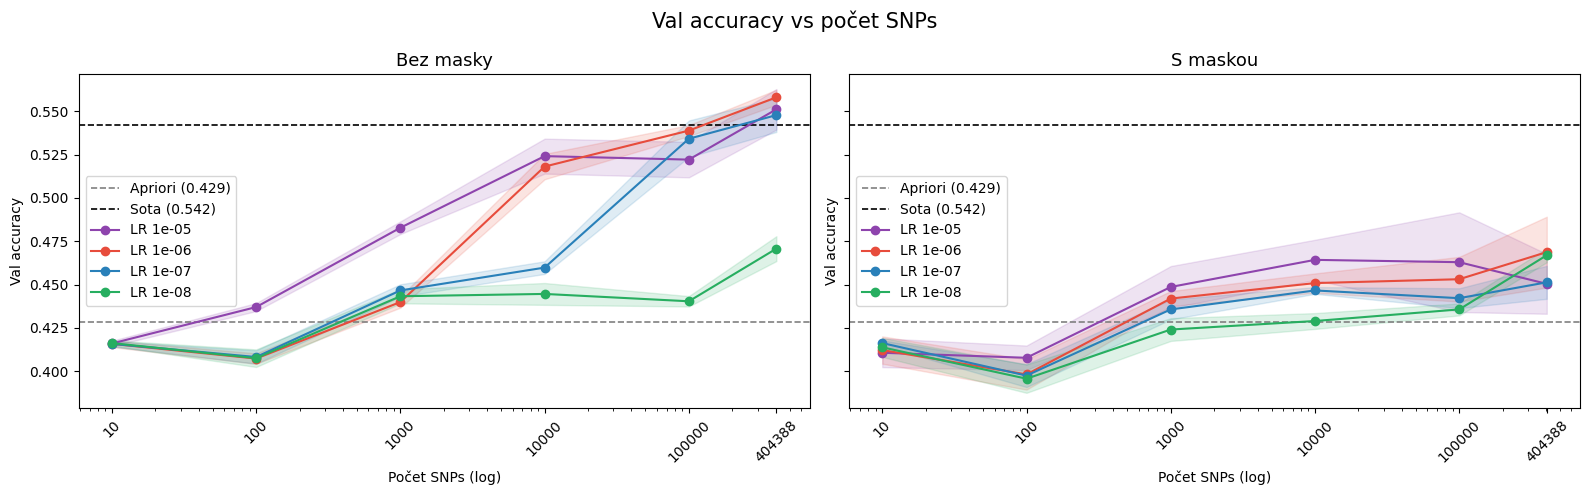

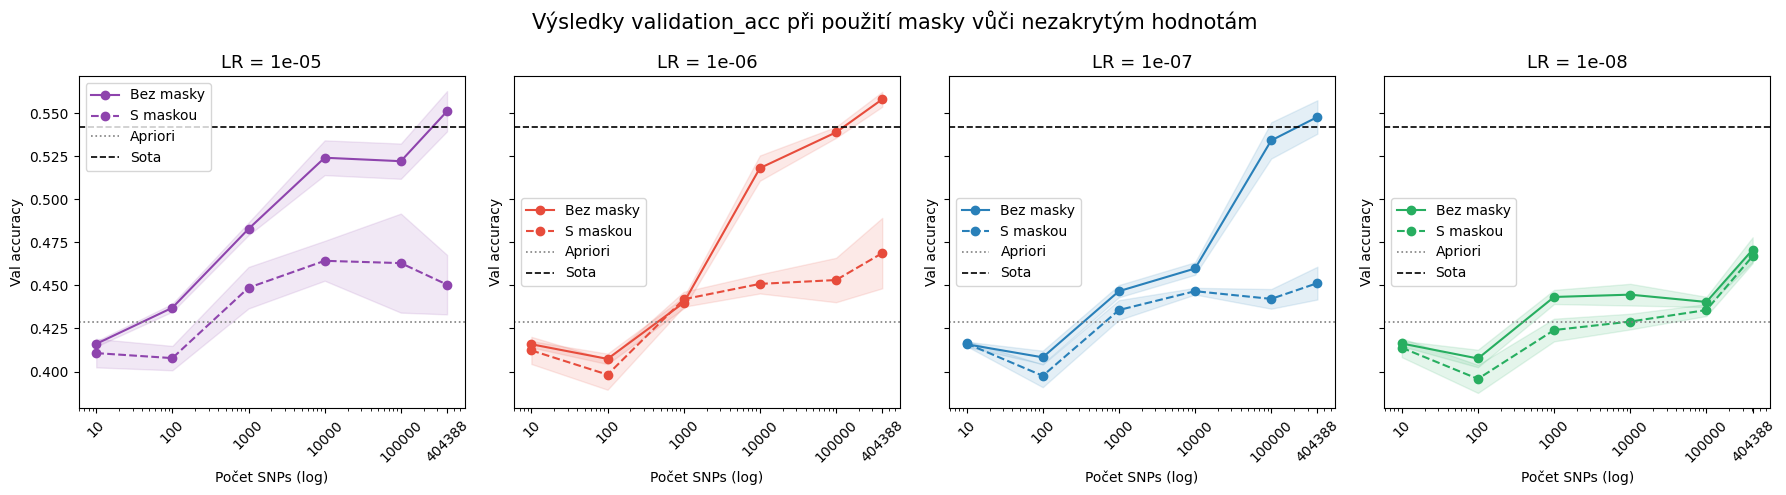

Uloženo: GRAPHS/PTH_reduction/PTH_03_nonbalanced_HM.svg


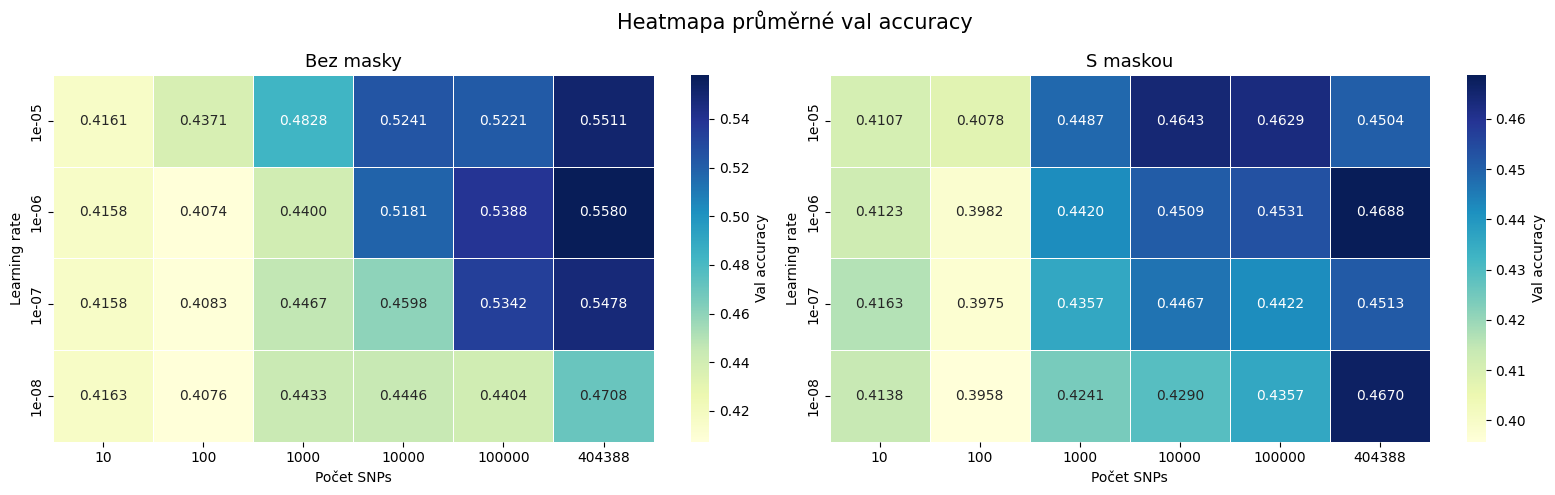

In [11]:
data = load_data(files)
agg = print_summary(data)
apriori = data['apriori_acc'].iloc[0]

plot_val_acc_by_mask(agg, apriori, sota=SOTA['PTH'], save={'filename': 'PTH_03_nonbalanced',
                                                            'directory': 'GRAPHS/PTH_reduction',
                                                            'dpi': 300,
                                                            'fmt': 'svg'})
plot_val_acc_by_lr(agg, apriori, sota=SOTA['PTH'])
plot_heatmap(data, save={'filename': 'PTH_03_nonbalanced_HM',
                         'directory': 'GRAPHS/PTH_reduction',
                         'dpi': 300,
                         'fmt': 'svg'})

In [12]:
def compute_and_compare(files_dict, phenotype, sota_dict=SOTA, sota_std_dict=SOTA_STD):
    """
    Compares custom experimental results against SOTA benchmarks for a given phenotype.
    Calculates mean and std for each result file provided.
    """
    print(f"Porovnání: {phenotype}")
    print(f"{'='*50}")
    
    results = {}
    
    if isinstance(files_dict, dict):
        items = list(files_dict.items())
    else:
        items = [(os.path.basename(p), p) for p in files_dict]

    first_df = pd.read_csv(items[0][1])
    if 'apriori_acc' in first_df.columns:
        apriori = first_df['apriori_acc'].iloc[0]
        print(f"Apriori accuracy: {apriori:.4f}")
        
    for name, path in items:
        df = pd.read_csv(path)
        if 'val_acc' not in df.columns:
            print(f"  [!] '{name}': sloupec 'val_acc' nenalezen, přeskakuji.")
            continue
        mean = df['val_acc'].mean()
        std  = df['val_acc'].std()
        results[name] = (mean, std)
        print(f"{name}  {mean:.4f} ± {std:.4f}")

    if phenotype in sota_dict:
        sota_mean = sota_dict[phenotype]
        sota_std  = sota_std_dict.get(phenotype, float('nan'))
        print(f"SOTA  {sota_mean:.4f} ± {sota_std:.4f}")
    
    print(f"{'='*50}\n")
    return results

In [13]:
files_apco = {
    'Test with kernel init': 'PHENO_RESULTS/APCO_REV_REPRO/APCO_REV_REPRO_LR1e-06.csv',
    'Test nonbalanced weights with kernel init':  'PHENO_RESULTS/APCO_REV_REPRO/APCO_REV_REPRO_nonbalanced.csv'
}

files_lpco = {
    'Test with kernel init': 'PHENO_RESULTS/LPCO_REV_POST/LPCO_REV_POST_LR1e-06.csv',
    'Test nonbalanced weights with kernel init':  'PHENO_RESULTS/LPCO_REV_POST/LPCO_REV_POST_nonbalanced.csv'
}

files_lsen = {
    'Test with kernel init': 'PHENO_RESULTS/LSEN/LSEN_LR1e-06.csv',
    'Test nonbalanced weights with kernel init':  'PHENO_RESULTS/LSEN/LSEN_nonbalanced.csv'
}

files_pex = {
    'Test with kernel init': 'PHENO_RESULTS/PEX_REPRO/PEX_REPRO_LR1e-06.csv',
    'Test nonbalanced weights with kernel init':  'PHENO_RESULTS/PEX_REPRO/PEX_REPRO_nonbalanced.csv'
}

files_pth = {
    'Test with kernel init': 'PHENO_RESULTS/PTH/PTH_LR1e-06.csv',
    'Test nonbalanced weights with kernel init':  'PHENO_RESULTS/PTH/PTH_nonbalanced.csv'
}

In [14]:
results = compute_and_compare(files_apco, phenotype='APCO_REV_REPRO')
results = compute_and_compare(files_lpco, phenotype='LPCO_REV_POST')
results = compute_and_compare(files_lsen, phenotype='LSEN')
results = compute_and_compare(files_pex, phenotype='PEX_REPRO')
results = compute_and_compare(files_pth, phenotype='PTH')

Porovnání: APCO_REV_REPRO
Apriori accuracy: 0.3894
Test with kernel init  0.4306 ± 0.0116
Test nonbalanced weights with kernel init  0.4413 ± 0.0061
SOTA  0.5020 ± 0.0180

Porovnání: LPCO_REV_POST
Apriori accuracy: 0.5648
Test with kernel init  0.4875 ± 0.0189
Test nonbalanced weights with kernel init  0.5772 ± 0.0089
SOTA  0.5920 ± 0.0163

Porovnání: LSEN
Apriori accuracy: 0.4447
Test with kernel init  0.4683 ± 0.0149
Test nonbalanced weights with kernel init  0.4734 ± 0.0040
SOTA  0.5060 ± 0.0108

Porovnání: PEX_REPRO
Apriori accuracy: 0.6073
Test with kernel init  0.5641 ± 0.0120
Test nonbalanced weights with kernel init  0.6243 ± 0.0077
SOTA  0.6190 ± 0.0059

Porovnání: PTH
Apriori accuracy: 0.4286
Test with kernel init  0.5545 ± 0.0129
Test nonbalanced weights with kernel init  0.5623 ± 0.0091
SOTA  0.5420 ± 0.0242

